In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns
from scipy.stats import wilcoxon
from scipy.signal import butter, sosfiltfilt, resample_poly

# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns
from scipy.stats import wilcoxon
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, welch


# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

In [2]:
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"

ri1_h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
}

ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [3]:
# Choose one by key
key = "RI1_3_6"   # change to whichever you want to test
h5_file = ri1_h5_paths[key]

print("Using:", h5_file)
print("Exists?", os.path.exists(h5_file))


Using: E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5
Exists? True


In [4]:
with h5py.File(h5_file, 'r') as f:
    print("Top-level keys:", list(f.keys()))


Top-level keys: ['ekg', 'ekg_metadata', 'metadata', 'resp', 'resp_metadata']


In [5]:
with h5py.File(h5_file, 'r') as f:
    # Try common places for fs
    fs = None

    # resp dataset attrs?
    if 'resp' in f:
        print("resp attrs:", dict(f['resp'].attrs))
        for k in ['sampling_rate','fs','rate','Fs','FS']:
            if k in f['resp'].attrs:
                fs = float(f['resp'].attrs[k])

    # metadata groups?
    for grp in ['resp_metadata','ekg_metadata','metadata','info']:
        if grp in f:
            print(f"{grp} attrs:", dict(f[grp].attrs))
            # fs directly?
            for k in ['sampling_rate','fs','rate','Fs','FS']:
                if k in f[grp].attrs and fs is None:
                    fs = float(f[grp].attrs[k])
            # or via duration
            if fs is None and 'duration_sec' in f[grp].attrs and 'resp' in f:
                dur = float(f[grp].attrs['duration_sec'])
                if dur > 0:
                    resp_len = len(f['resp'][:])
                    fs = resp_len / dur

print("Detected fs:", fs)


resp attrs: {}
resp_metadata attrs: {}
ekg_metadata attrs: {'channel_id': '21', 'duration_sec': 603.2723, 'num_samples': 12065446, 'sampling_frequency': 20000.0, 'stream_id': 'trodes'}
metadata attrs: {'date': '2025-06-21', 'negative_agent_id': 'RB3', 'positive_agent_id': '5.3', 'subject_id': '3.6', 'time': '12:53:12', 'trial_type': 'RI1'}
Detected fs: 20000.0


In [6]:
with h5py.File(h5_file, 'r') as f:
    resp = f['resp'][:].astype(float).flatten()

fs = 20000.0  # from ekg_metadata.sampling_frequency
dur_from_len = len(resp) / fs
print("len(resp):", len(resp))
print("fs (Hz):", fs)
print("duration from length (s):", dur_from_len)

len(resp): 12065446
fs (Hz): 20000.0
duration from length (s): 603.2723


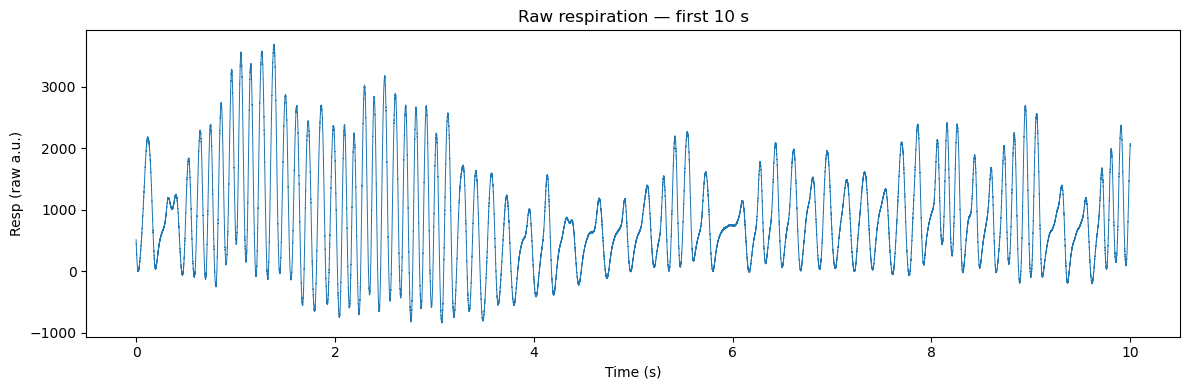

In [7]:
T = 10  # seconds
N = int(min(len(resp), fs*T))
t = np.arange(N) / fs

plt.figure(figsize=(12,4))
plt.plot(t, resp[:N], lw=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Resp (raw a.u.)")
plt.title("Raw respiration — first 10 s")
plt.tight_layout()
plt.show()


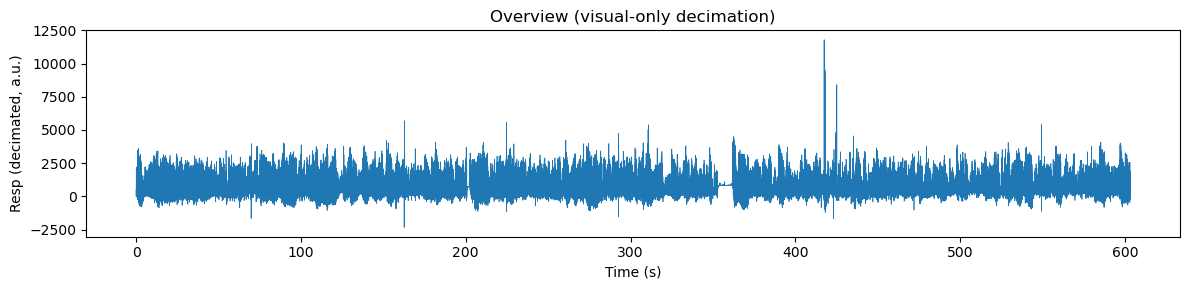

In [8]:
step = int(fs // 50)  # ~50 Hz view; for visualization ONLY
vis = resp[::step]
t_vis = np.arange(len(vis)) * (step / fs)

plt.figure(figsize=(12,3))
plt.plot(t_vis, vis, lw=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Resp (decimated, a.u.)")
plt.title("Overview (visual-only decimation)")
plt.tight_layout()
plt.show()


In [9]:
# 1) Anti-alias low-pass at 40 Hz BEFORE downsampling
#    (New Nyquist after DS to 100 Hz is 50 Hz, so 40 Hz is a safe guard band.)
sos_lp = butter(N=4, Wn=40.0, btype='low', fs=fs, output='sos')
resp_aa = sosfiltfilt(sos_lp, resp)   # zero-phase, stable

# 2) Downsample 20000 Hz -> ~100 Hz (use round in case fs isn't exact)
down = int(round(fs / 100.0))         # e.g. 200 for fs=20000
resp_ds = resample_poly(resp_aa, up=1, down=down)
fs_ds = fs / down                     # ≈100.0 Hz

# 3) Band-pass 0.5–15 Hz on the downsampled signal (breathing band)
sos_bp = butter(N=4, Wn=[0.5, 15.0], btype='bandpass', fs=fs_ds, output='sos')
resp_f = sosfiltfilt(sos_bp, resp_ds) # zero-phase again, stable

print("Original fs:", fs, "-> Downsampled fs:", fs_ds)
print("Lengths:", len(resp), "->", len(resp_f))


Original fs: 20000.0 -> Downsampled fs: 100.0
Lengths: 12065446 -> 60328


# Respiration Preprocessing Pipeline

This pipeline prepares raw respiration signals for analysis. It keeps the physiologically relevant breathing rhythms (0.5–15 Hz) and removes slow drifts and high-frequency noise.

---

## Step 1. Anti-alias low-pass filter at 40 Hz
**Plain English:**  
Before shrinking the signal, remove fast wiggles above 40 Hz. Otherwise, they would "fold back" (alias) into the slower breathing range.

**Math:**  
- Filter: 4th-order Butterworth, cutoff = 40 Hz  
- Normalized cutoff: $W_n = \frac{40}{f_s/2}$  
- Transfer function (digital IIR form):  

$$
H(z) = \frac{b_0 + b_1 z^{-1} + \dots + b_M z^{-M}}{1 + a_1 z^{-1} + \dots + a_N z^{-N}}
$$  

- Removes energy for $f > 40\ \text{Hz}$.

---

## Step 2. Downsample from ~20 kHz → 100 Hz
**Plain English:**  
Shrink the data so it’s not gigantic and focus on the breathing band (we don’t need 20,000 samples per second to capture 5–10 Hz breathing).

**Math:**  
- If original $f_s = 20{,}000$, down = 200 → new $f_s \approx 100$ Hz  
- New Nyquist = $f_s/2 = 50\ \text{Hz}$  
- Uses **polyphase resampling** (efficient, minimal aliasing)

---

## Step 3. Band-pass filter 0.5–15 Hz
**Plain English:**  
Keep only the breathing rhythm. Cut away very slow drifts and electrical/high-frequency noise.

**Math:**  
- 4th-order Butterworth band-pass  
- Cutoffs: $f_1 = 0.5\ \text{Hz}, f_2 = 15\ \text{Hz}$  
- For $f_s = 100$:  

$$
W_1 = \frac{0.5}{50} = 0.01, \quad W_2 = \frac{15}{50} = 0.3
$$  

- Passes $0.5 \leq f \leq 15$ Hz

---

## ✅ Final Result
A clean respiration signal:
- Sampled at ~100 Hz  
- Phase-corrected (via zero-phase `sosfiltfilt`)  
- Containing only the physiologically relevant breathing band


In [10]:
def preprocess_resp(resp, fs, target_rate=100):
    """
    Preprocess a raw respiration signal:
    
    Steps:
    1) Anti-alias low-pass filter at 40 Hz before downsampling.
       - Protects against aliasing by removing frequencies above the new Nyquist.
       - Implemented as a 4th-order Butterworth filter (zero-phase, stable).
    
    2) Downsample from original sampling rate (e.g., 20 kHz) to ~100 Hz.
       - Reduces data size and focuses on the physiological breathing band.
       - Uses polyphase resampling for efficiency.
    
    3) Band-pass filter from 0.5–15 Hz after downsampling.
       - Isolates breathing-related oscillations.
       - Removes very slow drifts (<0.5 Hz) and high-frequency noise (>15 Hz).
       - Implemented as a 4th-order Butterworth filter in SOS form, applied zero-phase.
    
    Parameters
    ----------
    resp : 1D array
        Raw respiration signal.
    fs : float
        Original sampling rate of the signal (Hz).
    target_rate : float, optional
        Desired downsampled rate (default=100 Hz).
    
    Returns
    -------
    resp_f : 1D array
        Preprocessed respiration signal (band-passed, downsampled).
    fs_ds : float
        Downsampled sampling rate.
    """
    
    # 1) Anti-alias low-pass filter at 40 Hz before downsampling
    sos_lp = butter(N=4, Wn=40.0, btype='low', fs=fs, output='sos')
    resp_aa = sosfiltfilt(sos_lp, resp)
    
    # 2) Downsample to ~100 Hz
    down = int(round(fs / target_rate))
    resp_ds = resample_poly(resp_aa, up=1, down=down)
    fs_ds = fs / down
    
    # 3) Band-pass filter 0.5–15 Hz
    sos_bp = butter(N=4, Wn=[0.5, 15.0], btype='bandpass', fs=fs_ds, output='sos')
    resp_f = sosfiltfilt(sos_bp, resp_ds)
    
    return resp_f, fs_ds


In [11]:
print("resp type:", type(resp))
print("resp shape:", np.shape(resp))
print("resp length:", len(resp))

resp type: <class 'numpy.ndarray'>
resp shape: (12065446,)
resp length: 12065446


In [12]:
# 1) Anti-alias low-pass at 40 Hz BEFORE downsampling
#    (New Nyquist after DS to 100 Hz is 50 Hz, so 40 Hz is a safe guard band.)
sos_lp = butter(N=4, Wn=40.0, btype='low', fs=fs, output='sos')
resp_aa = sosfiltfilt(sos_lp, resp)   # zero-phase, stable

# 2) Downsample 20000 Hz -> ~100 Hz (use round in case fs isn't exact)
down = int(round(fs / 100.0))         # e.g. 200 for fs=20000
resp_ds = resample_poly(resp_aa, up=1, down=down)
fs_ds = fs / down                     # ≈100.0 Hz

# 3) Band-pass 0.5–15 Hz on the downsampled signal (breathing band)
sos_bp = butter(N=4, Wn=[0.5, 15.0], btype='bandpass', fs=fs_ds, output='sos')
resp_f = sosfiltfilt(sos_bp, resp_ds) # zero-phase again, stable

print("Original fs:", fs, "-> Downsampled fs:", fs_ds)
print("Lengths:", len(resp), "->", len(resp_f))


Original fs: 20000.0 -> Downsampled fs: 100.0
Lengths: 12065446 -> 60328


In [13]:
print("resp type:", type(resp))
print("resp shape:", np.shape(resp))
print("resp length:", len(resp))

resp type: <class 'numpy.ndarray'>
resp shape: (12065446,)
resp length: 12065446


Dominant frequency: 9.80 Hz
Power fraction 6–12 Hz: 77.5%
Power fraction 1–4 Hz:  9.0%


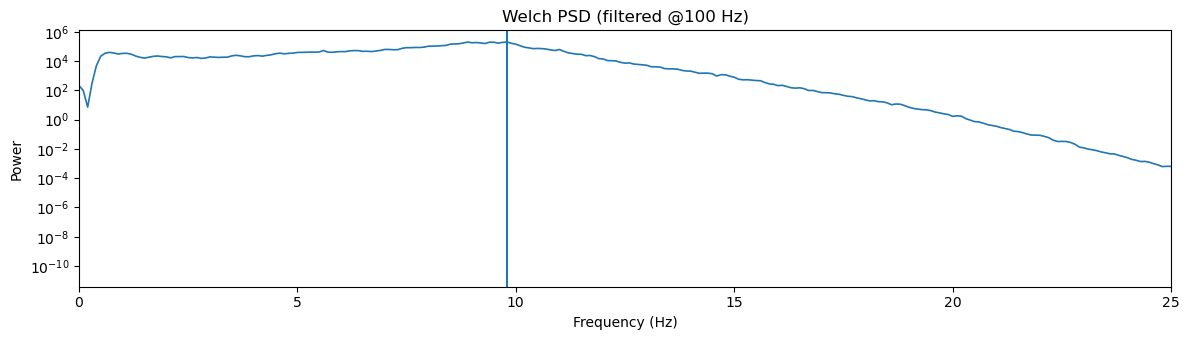

In [14]:
# PSD on filtered @100 Hz signal
nper = int(fs_ds*10)   # ~10 s windows for ~0.1 Hz resolution
f, pxx = welch(resp_f, fs=fs_ds, nperseg=nper, noverlap=nper//2, detrend='constant')

# Bands
resp_band = (f >= 0.5) & (f <= 15)
sniff_band = (f >= 6) & (f <= 12)
basal_band = (f >= 1) & (f <= 4)

# Dominant frequency within respiration band
f_peak = f[resp_band][np.argmax(pxx[resp_band])]

# Power fractions
total_power = pxx[resp_band].sum()
sniff_frac  = (pxx[sniff_band].sum() / total_power) if total_power > 0 else np.nan
basal_frac  = (pxx[basal_band].sum() / total_power) if total_power > 0 else np.nan

print(f"Dominant frequency: {f_peak:.2f} Hz")
print(f"Power fraction 6–12 Hz: {sniff_frac:.1%}")
print(f"Power fraction 1–4 Hz:  {basal_frac:.1%}")

# Plot with a marker at the peak (colors are optional; remove if you prefer defaults)
plt.figure(figsize=(12,3.5))
plt.semilogy(f, pxx, lw=1.2)
plt.axvline(f_peak)  # marks the dominant freq
plt.xlim(0, 25)
plt.xlabel("Frequency (Hz)"); plt.ylabel("Power")
plt.title("Welch PSD (filtered @100 Hz)")
plt.tight_layout(); plt.show()


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from moviepy.editor import VideoFileClip, VideoClip, clips_array
import os

def make_aligned_video(resp, fs_resp, video_path, out_path="aligned_output.mp4", fps=30):
    """
    Create a side-by-side video of mouse behavior (left) and respiration trace (right).

    Parameters
    ----------
    resp : 1D numpy array
        Respiration signal (already preprocessed), sampled at fs_resp (e.g., 100 Hz).
    fs_resp : float
        Respiration sampling rate in Hz (e.g., 100).
    video_path : str
        Path to the mouse video file (e.g., "mouse_video.mp4").
    out_path : str, optional
        Output file path for the combined video (default = "aligned_output.mp4").
    fps : int, optional
        Frames per second of the output video (default = 30).

    Returns
    -------
    None (writes combined video to out_path).
    """

    # Load video
    video = VideoFileClip(video_path)
    duration = video.duration
    n_frames = int(duration * fps)

    # Time axis for respiration
    t_resp = np.arange(len(resp)) / fs_resp

    # Function to draw respiration plot at each video time
    def make_plot(t):
        plt.figure(figsize=(6, 3))
        plt.plot(t_resp, resp, color="blue", lw=1)
        plt.axvline(t, color="red", linestyle="--", lw=2, label="video time")
        plt.xlim(t - 5, t + 5)  # show a 10-second moving window
        plt.ylim(np.min(resp), np.max(resp))
        plt.xlabel("Time (s)")
        plt.ylabel("Respiration (a.u.)")
        plt.title("Respiration trace (100 Hz)")
        plt.tight_layout()
        fname = "temp.png"
        plt.savefig(fname, dpi=100)
        plt.close()
        return fname

    # Create animated respiration clip
    resp_clip = VideoClip(make_plot, duration=duration).set_fps(fps)

    # Combine side by side
    final = clips_array([[video.resize(height=300), resp_clip.resize(height=300)]])
    final.write_videofile(out_path, fps=fps)

    # Clean up
    if os.path.exists("temp.png"):
        os.remove("temp.png")


In [16]:
import os
import moviepy
print(moviepy.__file__)
print(os.listdir(os.path.dirname(moviepy.__file__)))


c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\moviepy\__init__.py
['audio', 'Clip.py', 'compat.py', 'config.py', 'config_defaults.py', 'decorators.py', 'editor.py', 'tools.py', 'utils.py', 'version.py', 'video', '__init__.py', '__pycache__']


In [17]:
!{sys.executable} -m pip uninstall -y moviepy
!{sys.executable} -m pip install moviepy==1.0.3


'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.
'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


In [18]:
import h5py
import numpy as np

# Full path to your h5 file
h5_file = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"

# Inspect datasets inside the file
with h5py.File(h5_file, "r") as f:
    print("Datasets available:", list(f.keys()))
    # Example: if 'resp' exists
    resp = f['resp'][:]      # raw respiration signal



Datasets available: ['ekg', 'ekg_metadata', 'metadata', 'resp', 'resp_metadata']


In [19]:
resp = np.array(resp).astype(float).flatten()


In [20]:
resp_f, fs_resp = preprocess_resp(resp, fs=20000, target_rate=100)

print("Filtered signal length:", len(resp_f))
print("New fs:", fs_resp, "Hz")
print("Duration (s):", len(resp_f)/fs_resp)


Filtered signal length: 62374
New fs: 100.0 Hz
Duration (s): 623.74


In [21]:
import h5py, numpy as np, matplotlib.pyplot as plt, io
from moviepy.editor import VideoFileClip, VideoClip, clips_array
from PIL import Image, ImageDraw
from tqdm import tqdm   # progress bar

def make_aligned_movie_from_h5_fast(h5_file, video_path, out_path, fs_raw=20000, target_rate=100, fps=30):
    from scipy.signal import butter, sosfiltfilt, resample_poly
    
    # --- Load respiration ---
    with h5py.File(h5_file, "r") as f:
        resp = f['resp'][:].squeeze().astype(float)

    # --- Preprocess (20 kHz -> 100 Hz, band 0.5-15 Hz) ---
    sos_lp = butter(4, 40, btype='low', fs=fs_raw, output='sos')
    resp_aa = sosfiltfilt(sos_lp, resp)
    down = int(round(fs_raw / target_rate))
    resp_ds = resample_poly(resp_aa, up=1, down=down)
    fs_ds = fs_raw / down
    sos_bp = butter(4, [0.5, 15], btype='bandpass', fs=fs_ds, output='sos')
    resp_f = sosfiltfilt(sos_bp, resp_ds)
    t_resp = np.arange(len(resp_f)) / fs_ds

    # --- Render static respiration trace once ---
    fig, ax = plt.subplots(figsize=(8,3))
    ax.plot(t_resp, resp_f, color="blue", lw=1)
    ax.set_xlim(0, t_resp[-1])
    ax.set_ylim(np.min(resp_f), np.max(resp_f))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Respiration (a.u.)")
    ax.set_title("Respiration trace (100 Hz)")
    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    plt.close(fig)
    buf.seek(0)
    background = Image.open(buf).convert("RGB")
    width, height = background.size

    # --- Load video ---
    video = VideoFileClip(video_path)
    duration = video.duration
    total_frames = int(duration * fps)

    # --- Overlay only a red line per frame ---
    pbar = tqdm(total=total_frames, desc="Rendering respiration overlay")
    def make_frame(t):
        img = background.copy()
        draw = ImageDraw.Draw(img)
        line_x = int((t / duration) * width)
        draw.line([(line_x, 0), (line_x, height)], fill="red", width=3)
        pbar.update(1)
        return np.array(img)

    resp_clip = VideoClip(make_frame, duration=duration).set_fps(fps)
    final = clips_array([[video.resize(height=300), resp_clip.resize(height=300)]])
    final.write_videofile(out_path, fps=fps)
    pbar.close()

    print(f"✅ Done! Exported {out_path}")


In [22]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.animation as animation

x = np.linspace(0, 2*np.pi, 200)
y = np.sin(x)

fig, ax = plt.subplots()
line, = ax.plot(x, y)
ax.set_ylim(-1.2, 1.2)

def update(frame):
    line.set_ydata(np.sin(x + frame/10))
    return line,

ani = animation.FuncAnimation(fig, update, frames=100, interval=50, blit=True)
ani.save("sine_test.mp4", writer="ffmpeg", fps=20)
plt.close(fig)

print("✅ Sine test video saved as sine_test.mp4")


✅ Sine test video saved as sine_test.mp4


In [23]:
import h5py, numpy as np, matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.signal import butter, sosfiltfilt, resample_poly

def export_resp_trace_video(h5_file, out_path, fs_raw=20000, target_rate=100, fps=30, duration_limit=None):
    """
    Export respiration trace with a moving red line as a standalone MP4.
    duration_limit: if not None, limit to N seconds (for quick testing).
    """
    # --- Load respiration ---
    with h5py.File(h5_file, "r") as f:
        resp = f['resp'][:].squeeze().astype(float)

    # --- Preprocess (20 kHz → 100 Hz, band 0.5–15 Hz) ---
    sos_lp = butter(4, 40, btype='low', fs=fs_raw, output='sos')
    resp_aa = sosfiltfilt(sos_lp, resp)
    down = int(round(fs_raw / target_rate))
    resp_ds = resample_poly(resp_aa, up=1, down=down)
    fs_ds = fs_raw / down
    sos_bp = butter(4, [0.5, 15], btype='bandpass', fs=fs_ds, output='sos')
    resp_f = sosfiltfilt(sos_bp, resp_ds)
    t_resp = np.arange(len(resp_f)) / fs_ds

    # Optionally shorten for testing
    if duration_limit is not None:
        max_samples = int(duration_limit * fs_ds)
        resp_f = resp_f[:max_samples]
        t_resp = t_resp[:max_samples]

    # --- Make animation ---
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t_resp, resp_f, color="blue", lw=1)
    line = ax.axvline(0, color="red", linestyle="--", lw=2)
    ax.set_xlim(0, t_resp[-1])
    ax.set_ylim(np.min(resp_f), np.max(resp_f))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Respiration (a.u.)")
    ax.set_title("Respiration trace (100 Hz)")
    plt.tight_layout()

    def update(frame):
        line.set_xdata([frame / fps])  # must be a sequence
        return (line,)

    ani = animation.FuncAnimation(fig, update, frames=int(t_resp[-1] * fps),
                                  interval=1000/fps, blit=True)
    ani.save(out_path, writer="ffmpeg", fps=fps)
    plt.close(fig)

    print(f"✅ Respiration trace movie saved to {out_path}")


In [24]:
h5_file = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"
out_path = r"E:\Aim1\AIM1\Day1_new\resp_trace_only_test30s.mp4"

export_resp_trace_video(h5_file, out_path, duration_limit=30, fps=20)


✅ Respiration trace movie saved to E:\Aim1\AIM1\Day1_new\resp_trace_only_test30s.mp4


In [25]:
def export_resp_trace_video_window(h5_file, out_path, fs_raw=20000, target_rate=100,
                                   fps=30, duration_limit=None, window_size=5):
    """
    Export respiration trace with a sliding window view (default 5s).
    Shows clear oscillations instead of full trial compression.
    """
    import h5py, numpy as np, matplotlib.pyplot as plt
    import matplotlib.animation as animation
    from scipy.signal import butter, sosfiltfilt, resample_poly

    # --- Load respiration ---
    with h5py.File(h5_file, "r") as f:
        resp = f['resp'][:].squeeze().astype(float)

    # --- Preprocess (20 kHz → 100 Hz, band 0.5–15 Hz) ---
    sos_lp = butter(4, 40, btype='low', fs=fs_raw, output='sos')
    resp_aa = sosfiltfilt(sos_lp, resp)
    down = int(round(fs_raw / target_rate))
    resp_ds = resample_poly(resp_aa, up=1, down=down)
    fs_ds = fs_raw / down
    sos_bp = butter(4, [0.5, 15], btype='bandpass', fs=fs_ds, output='sos')
    resp_f = sosfiltfilt(sos_bp, resp_ds)
    t_resp = np.arange(len(resp_f)) / fs_ds

    # Optionally shorten for testing
    if duration_limit is not None:
        max_samples = int(duration_limit * fs_ds)
        resp_f = resp_f[:max_samples]
        t_resp = t_resp[:max_samples]

    # --- Setup figure ---
    fig, ax = plt.subplots(figsize=(8, 4))
    line, = ax.plot([], [], color="blue", lw=1)
    marker = ax.axvline(0, color="red", linestyle="--", lw=2)
    ax.set_ylim(np.min(resp_f), np.max(resp_f))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Respiration (a.u.)")
    ax.set_title("Respiration trace (sliding window)")
    plt.tight_layout()

    # --- Update function (sliding window) ---
    def update(frame):
        current_time = frame / fps
        start = max(0, int((current_time - window_size/2) * fs_ds))
        end   = min(len(resp_f), int((current_time + window_size/2) * fs_ds))
        line.set_data(t_resp[start:end], resp_f[start:end])
        ax.set_xlim(current_time - window_size/2, current_time + window_size/2)
        marker.set_xdata([current_time])
        return line, marker

    ani = animation.FuncAnimation(fig, update, frames=int(t_resp[-1] * fps),
                                  interval=1000/fps, blit=True)
    ani.save(out_path, writer="ffmpeg", fps=fps)
    plt.close(fig)

    print(f"✅ Sliding-window respiration movie saved to {out_path}")


In [26]:
h5_file = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"
out_path = r"E:\Aim1\AIM1\Day1_new\resp_trace_window_test30s.mp4"

export_resp_trace_video_window(h5_file, out_path, duration_limit=30, fps=20, window_size=5)


✅ Sliding-window respiration movie saved to E:\Aim1\AIM1\Day1_new\resp_trace_window_test30s.mp4


MovieWriter stderr:
[vost#0:0/libx264 @ 0000029BBC804040] Error submitting a packet to the muxer: Permission denied
    Last message repeated 1 times
[out#0/mp4 @ 0000029BBC78DA00] Error muxing a packet
[out#0/mp4 @ 0000029BBC78DA00] Task finished with error code: -13 (Permission denied)
[out#0/mp4 @ 0000029BBC78DA00] Terminating thread with return code -13 (Permission denied)
[out#0/mp4 @ 0000029BBC78DA00] Error writing trailer: Permission denied
[out#0/mp4 @ 0000029BBC78DA00] Error closing file: Permission denied



CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '800x400', '-pix_fmt', 'rgba', '-framerate', '30', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', 'E:\\Aim1\\AIM1\\Day1_new\\resp_trace_window_test30s.mp4']' returned non-zero exit status 4294967283.

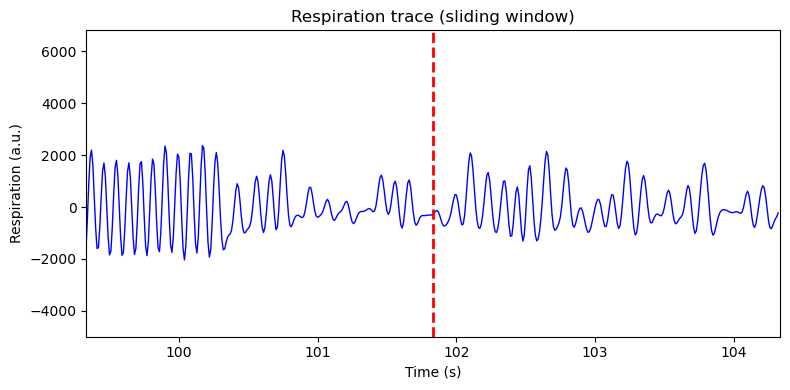

In [27]:
h5_file = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"
resp_out = r"E:\Aim1\AIM1\Day1_new\resp_trace_window_test30s.mp4"

export_resp_trace_video_window(
    h5_file, 
    resp_out, 
    duration_limit=300,   # only first 30 seconds
    fps=30,              # lighter than 30 fps, still smooth
    window_size=5        # 5 s view of breathing oscillations
)


In [ ]:
h5_file_RI1_3_6 = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
resp_out = r"E:\Aim1\AIM1\Day1_new\RI1_3_6_resp_trace_window_300s.mp4"

export_resp_trace_video_window(
    h5_file, 
    resp_out, 
    duration_limit=300,   # only first 30 seconds
    fps=30,              # lighter than 30 fps, still smooth
    window_size=5        # 5 s view of breathing oscillations
)

In [ ]:
h5_file_RI2_4_7 = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
resp_out = r"E:\Aim1\AIM1\Day1_new\RI2_4_7_resp_trace_window_300s.mp4"

export_resp_trace_video_window(
    h5_file, 
    resp_out, 
    duration_limit=300,   # only first 30 seconds
    fps=30,              # lighter than 30 fps, still smooth
    window_size=5        # 5 s view of breathing oscillations
)


✅ Sliding-window respiration movie saved to E:\Aim1\AIM1\Day1_new\RI2_4_7_resp_trace_window_300s.mp4
